# Telco Customer churn

## Objective

Explore the Telco Customer Churn dataset to understand which customer attributes are associated with churn, identify data quality issues that need to be handled in preprocessing, and decide which features carry signal and which do not. The target is the `Churn` column (binary: customer left or stayed).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from  scipy.stats import chi2_contingency 

In [2]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")

In [3]:
df.shape

(7043, 21)

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
print(df.duplicated().sum())
print(df.isnull().sum())

0
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"] , errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median() , inplace=True)
df.isnull().sum()

C:\Users\bc\AppData\Local\Temp\ipykernel_7204\1422006835.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median() , inplace=True)


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df.describe(include=object)

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


In [10]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

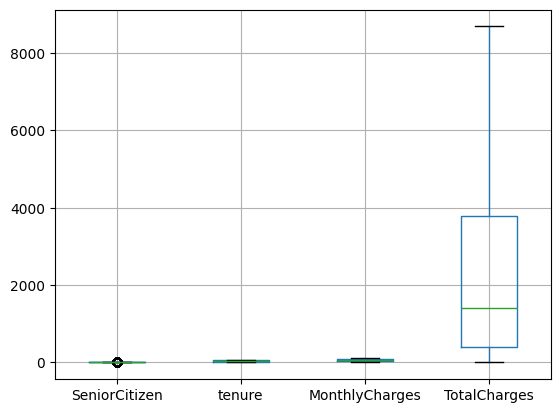

In [11]:
df.boxplot()
plt.show()

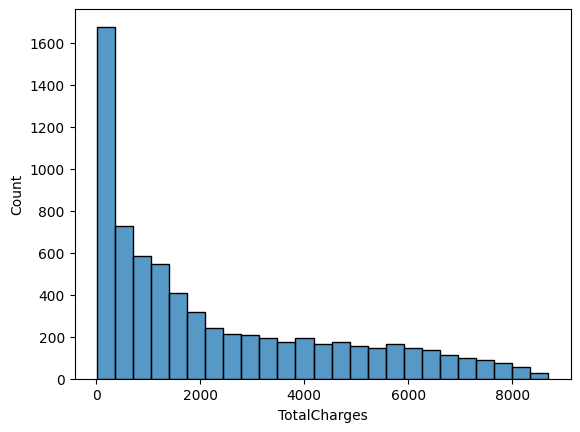

In [12]:
sns.histplot(data=df ,x="TotalCharges" )
plt.show()

In [13]:
from sklearn.preprocessing import label_binarize
df["Churn"] = label_binarize(df["Churn"], classes=['No','Yes'])

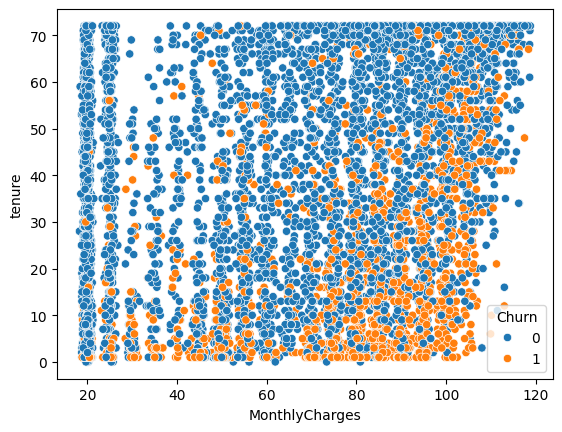

In [14]:
sns.scatterplot(data=df , x="MonthlyCharges" , y="tenure" ,hue= "Churn")
plt.show()

Churn
0    2552.882494
1    1531.796094
Name: TotalCharges, dtype: float64


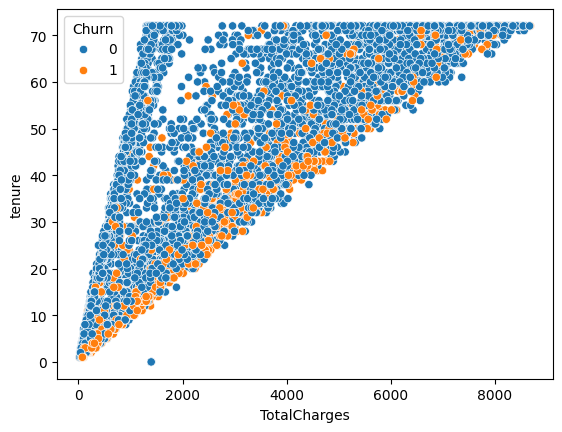

In [15]:
print(df.groupby("Churn")["TotalCharges"].mean())
sns.scatterplot(data= df , y="tenure" , x="TotalCharges" , hue="Churn")
plt.show()

In [16]:
df[df["tenure"] == 0][["tenure" ,"MonthlyCharges" , "TotalCharges" , "Churn"]]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,1397.475,0
753,0,20.25,1397.475,0
936,0,80.85,1397.475,0
1082,0,25.75,1397.475,0
1340,0,56.05,1397.475,0
3331,0,19.85,1397.475,0
3826,0,25.35,1397.475,0
4380,0,20.00,1397.475,0
5218,0,19.70,1397.475,0
6670,0,73.35,1397.475,0


MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64


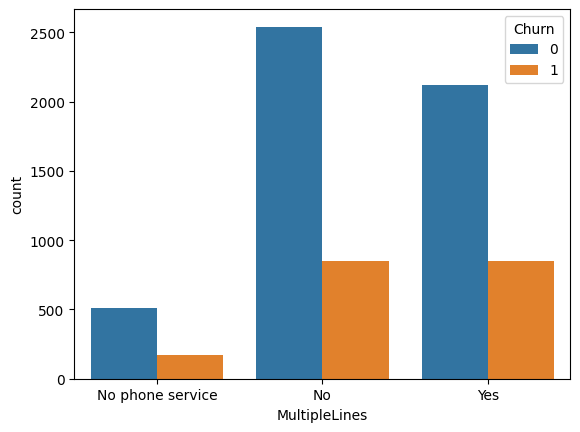

In [17]:
print(df["MultipleLines"].value_counts())
sns.countplot(data=df , x ="MultipleLines" , hue="Churn")
plt.show()

PhoneService
Yes    6361
No      682
Name: count, dtype: int64


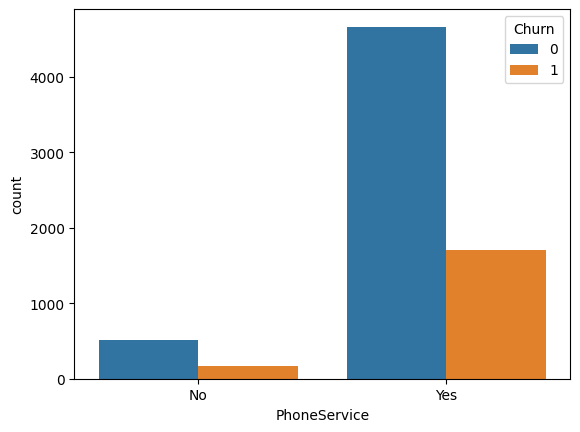

Churn                 0          1
PhoneService                      
No            75.073314  24.926686
Yes           73.290363  26.709637


In [18]:
print(df["PhoneService"].value_counts())
sns.countplot(data=df , x ="PhoneService" , hue="Churn")
plt.show()
print(pd.crosstab(df["PhoneService"],df["Churn"],normalize="index")*100)

Dependents
No     0.312791
Yes    0.154502
Name: Churn, dtype: float64


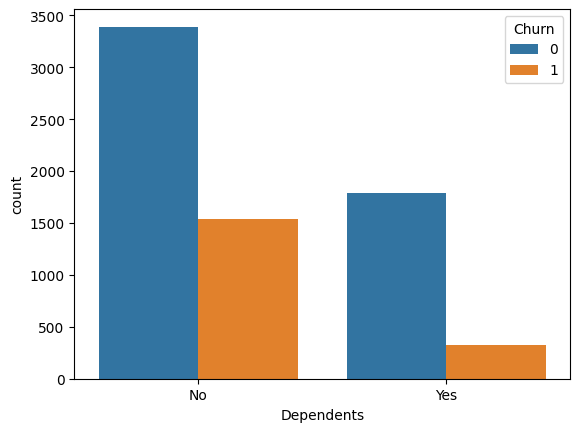

In [19]:
print(df.groupby("Dependents")["Churn"].mean())
sns.countplot(data=df ,x="Dependents" , hue="Churn")
plt.show()

OnlineBackup
No                     0.399288
No internet service    0.074050
Yes                    0.215315
Name: Churn, dtype: float64


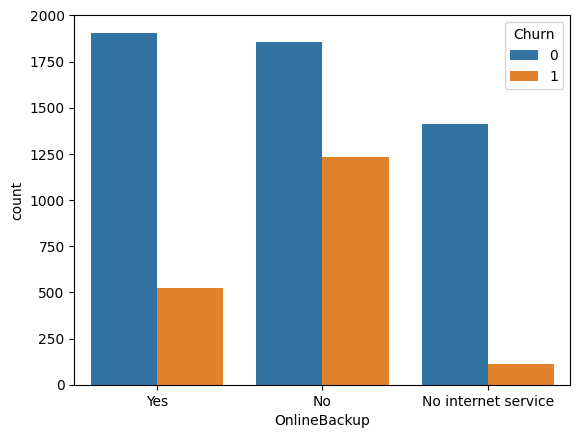

Churn                        0          1
OnlineBackup                             
No                   60.071244  39.928756
No internet service  92.595020   7.404980
Yes                  78.468506  21.531494


In [20]:
print(df.groupby("OnlineBackup")["Churn"].mean())
sns.countplot(data=df ,x="OnlineBackup" , hue="Churn")
plt.show()
print(pd.crosstab(df["OnlineBackup"] , df["Churn"] , normalize="index")*100)

InternetService
DSL            0.189591
Fiber optic    0.418928
No             0.074050
Name: Churn, dtype: float64


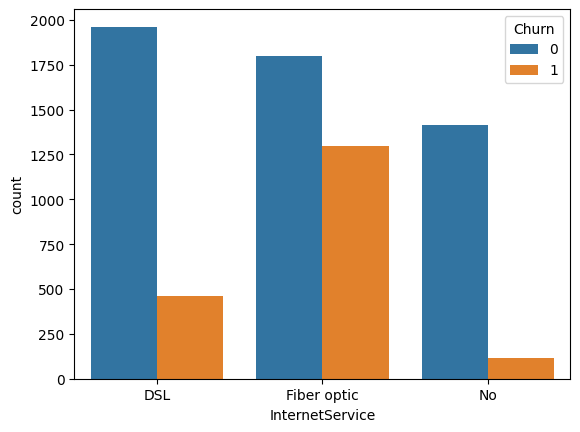

Churn               0     1
InternetService            
DSL              1962   459
Fiber optic      1799  1297
No               1413   113


In [21]:
print(df.groupby("InternetService")["Churn"].mean())
sns.countplot(data=df, x="InternetService" , hue="Churn" )
plt.show()
print(pd.crosstab(df["InternetService"] , df["Churn"]))

OnlineSecurity
No                     0.417667
No internet service    0.074050
Yes                    0.146112
Name: Churn, dtype: float64


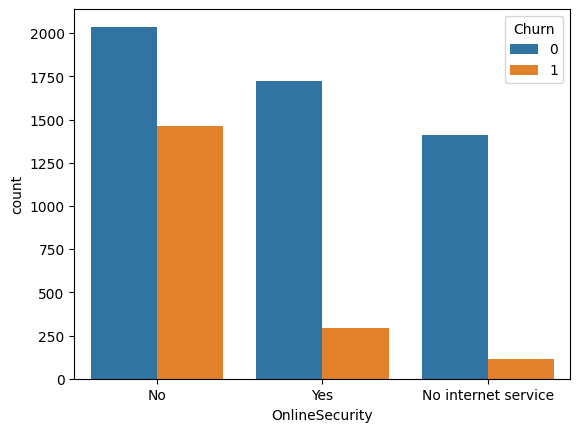

Churn                   0     1
OnlineSecurity                 
No                   2037  1461
No internet service  1413   113
Yes                  1724   295


In [22]:
print(df.groupby("OnlineSecurity")["Churn"].mean())
sns.countplot(data=df, x="OnlineSecurity" , hue="Churn" )
plt.show()
print(pd.crosstab(df["OnlineSecurity"] , df["Churn"]))

DeviceProtection
No                     0.391276
No internet service    0.074050
Yes                    0.225021
Name: Churn, dtype: float64


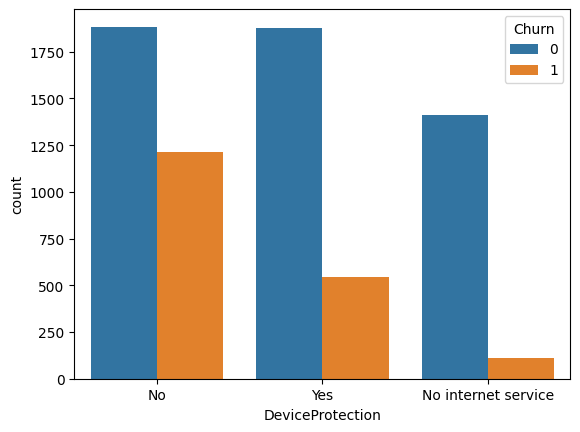

Churn                        0          1
DeviceProtection                         
No                   60.872375  39.127625
No internet service  92.595020   7.404980
Yes                  77.497936  22.502064


In [23]:
print(df.groupby("DeviceProtection")["Churn"].mean())
sns.countplot(data= df , x= "DeviceProtection" , hue="Churn")
plt.show()
print(pd.crosstab(df["DeviceProtection"] , df["Churn"] , normalize="index") *100)

StreamingTV
No                     0.335231
No internet service    0.074050
Yes                    0.300702
Name: Churn, dtype: float64


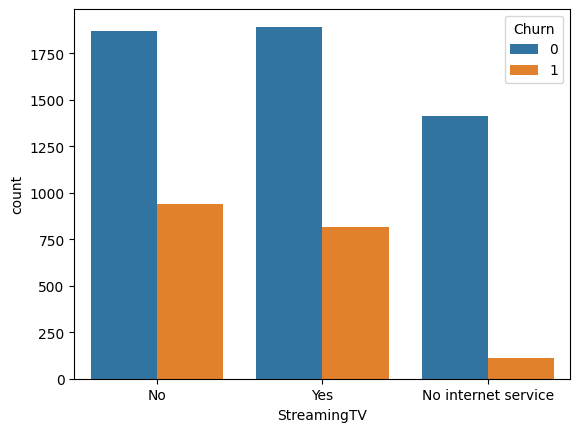

Churn                        0          1
StreamingTV                              
No                   66.476868  33.523132
No internet service  92.595020   7.404980
Yes                  69.929812  30.070188


In [24]:
print(df.groupby("StreamingTV")["Churn"].mean())
sns.countplot(data=df , x="StreamingTV" , hue="Churn")
plt.show()
print(pd.crosstab(df["StreamingTV"] , df["Churn"] , normalize="index")*100)

StreamingMovies
No                     0.336804
No internet service    0.074050
Yes                    0.299414
Name: Churn, dtype: float64


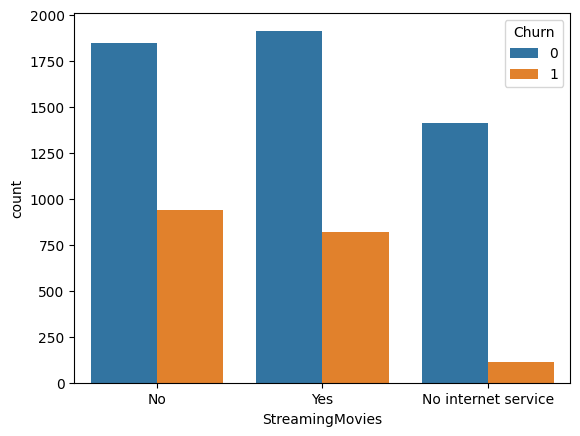

Churn                        0          1
StreamingMovies                          
No                   66.319569  33.680431
No internet service  92.595020   7.404980
Yes                  70.058565  29.941435


In [25]:
print(df.groupby("StreamingMovies")["Churn"].mean())
sns.countplot(data=df , x="StreamingMovies" , hue="Churn")
plt.show()
print(pd.crosstab(df["StreamingMovies"] , df["Churn"] , normalize="index")*100)

In [26]:
pd.crosstab(df["StreamingMovies"] , df["StreamingTV"] )

StreamingTV,No,No internet service,Yes
StreamingMovies,,,
No,2018,0,767
No internet service,0,1526,0
Yes,792,0,1940


In [27]:
table = pd.crosstab(df["StreamingMovies"] , df["StreamingTV"])

chi2 = chi2_contingency(table)[0]

n = table.sum().sum()

r ,k = table.shape
cramers_v = np.sqrt(chi2 / (n * min(r-1 , k-1 )))

print(cramers_v)

0.7710419124234426


PaperlessBilling
No     0.163301
Yes    0.335651
Name: Churn, dtype: float64


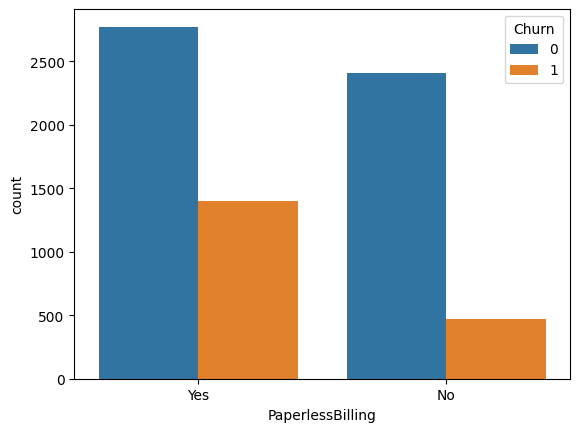

Churn                     0          1
PaperlessBilling                      
No                83.669916  16.330084
Yes               66.434908  33.565092


In [28]:
print(df.groupby("PaperlessBilling")["Churn"].mean())
sns.countplot(data=df , x="PaperlessBilling" , hue="Churn")
plt.show()
print(pd.crosstab(df["PaperlessBilling"] , df["Churn"] , normalize="index")*100)

PaymentMethod
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Electronic check             0.452854
Mailed check                 0.191067
Name: Churn, dtype: float64


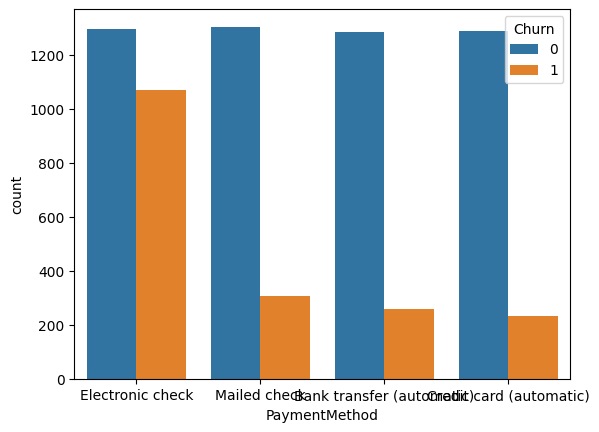

Churn                              0          1
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


In [29]:
print(df.groupby("PaymentMethod")["Churn"].mean())
sns.countplot(data=df , x="PaymentMethod" , hue="Churn")
plt.show()
print(pd.crosstab(df["PaymentMethod"] , df["Churn"] , normalize="index")*100)

In [30]:
print(df.groupby("PaymentMethod")["MonthlyCharges"].mean())
print(df.groupby("PaymentMethod")["TotalCharges"].mean())

PaymentMethod
Bank transfer (automatic)    67.192649
Credit card (automatic)      66.512385
Electronic check             76.255814
Mailed check                 43.917060
Name: MonthlyCharges, dtype: float64
PaymentMethod
Bank transfer (automatic)    3077.121017
Credit card (automatic)      3070.296206
Electronic check             2090.868182
Mailed check                 1056.186104
Name: TotalCharges, dtype: float64


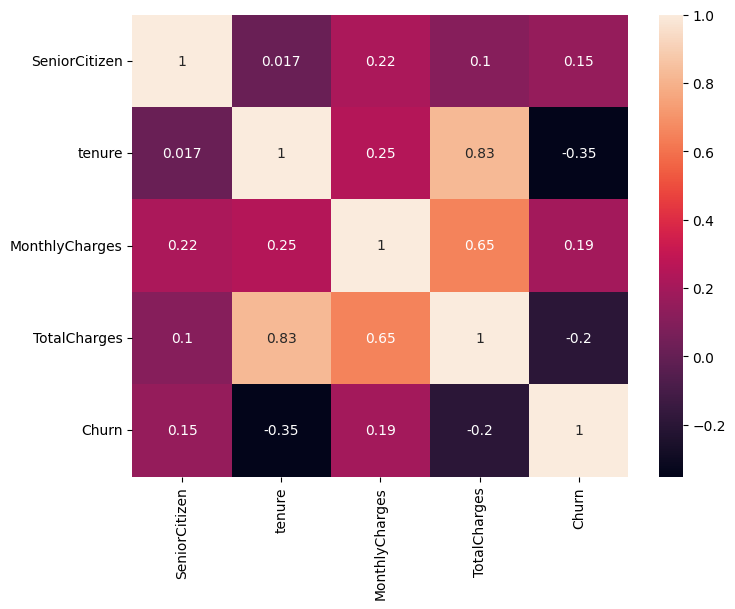

In [31]:
plt.figure(figsize=(8,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr ,annot=True)
plt.show()

In [32]:
corr = df.corr(numeric_only=True)
print(corr * 100)
corr["Churn"].sort_values()

                SeniorCitizen      tenure  MonthlyCharges  TotalCharges  \
SeniorCitizen      100.000000    1.656688       22.017334     10.265159   
tenure               1.656688  100.000000       24.789986     82.546409   
MonthlyCharges      22.017334   24.789986      100.000000     65.086435   
TotalCharges        10.265159   82.546409       65.086435    100.000000   
Churn               15.088933  -35.222867       19.335642    -19.903683   

                     Churn  
SeniorCitizen    15.088933  
tenure          -35.222867  
MonthlyCharges   19.335642  
TotalCharges    -19.903683  
Churn           100.000000  


tenure           -0.352229
TotalCharges     -0.199037
SeniorCitizen     0.150889
MonthlyCharges    0.193356
Churn             1.000000
Name: Churn, dtype: float64

In [33]:
df.groupby('Churn')["tenure"].mean()

Churn
0    37.569965
1    17.979133
Name: tenure, dtype: float64

In [34]:
df.groupby("Contract")["Churn"].mean()

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64

In [35]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,0,1
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [36]:
print(df.groupby("gender")["Churn"].mean())
pd.crosstab(df["gender"], df["Churn"])

gender
Female    0.269209
Male      0.261603
Name: Churn, dtype: float64


Churn,0,1
gender,,
Female,2549,939
Male,2625,930


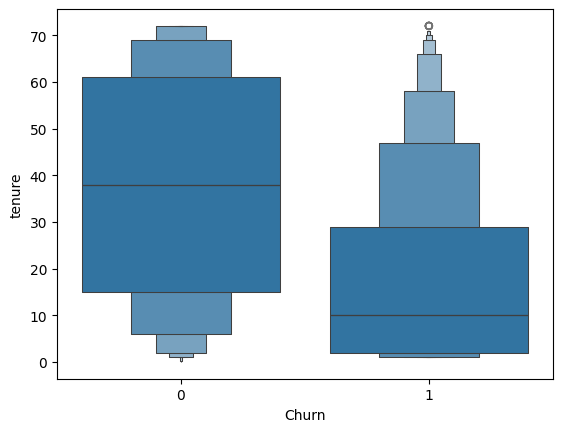

In [37]:
sns.boxenplot(data=df , x="Churn", y="tenure")
plt.show()

## EDA Conclusions

### Features to Drop
- customerID (unique identifier per row, no predictive value)

### Numerical Features
- tenure
- MonthlyCharges
- TotalCharges

### Binary Features
- gender
- Partner
- Dependents
- PhoneService
- PaperlessBilling

### Categorical Features
- MultipleLines
- InternetService
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies
- Contract
- PaymentMethod

### Target
- Churn (imbalanced: 5174 No / 1869 Yes, ~26.5% positive class)

### Data Quality Issues
- TotalCharges is stored as `object` dtype because 11 rows (all with `tenure == 0`, i.e. brand-new customers) have a blank string instead of a number. Converted with `pd.to_numeric(errors="coerce")` and filled with the median.
- Those same 11 rows all share the exact same TotalCharges value after the fill (the global median), which is expected since they were all missing and got the same imputed value — not a separate data error, just a side effect of the imputation.
- No duplicate rows, no other missing values.

### Important Findings
- **Contract type is the strongest categorical driver of churn**: Month-to-month churn rate is 42.7%, vs 11.3% for One year and only 2.8% for Two year contracts.
- **tenure has the strongest numeric correlation with Churn** (-0.35): churned customers have an average tenure of ~18 months vs ~38 months for retained customers.
- **PaymentMethod matters**: Electronic check has a churn rate of 45.3%, roughly 2.5x higher than the other three payment methods (~15-19%).
- **Fiber optic InternetService churns more** than DSL (41.9% vs 19.0%), despite being the more expensive/premium option — worth flagging as a possible service-quality or pricing issue, not just a modeling detail.
- **Lack of add-on services correlates with churn**: customers without OnlineSecurity (41.8% churn) or OnlineBackup (39.9% churn) churn much more than those with these services.
- **PaperlessBilling and no Dependents also correlate with higher churn** (33.6% vs 16.3%, and 31.3% vs 15.5% respectively), though these look secondary compared to Contract, tenure and PaymentMethod.
- **StreamingTV and StreamingMovies are highly redundant with each other** (Cramér's V = 0.77) and only weakly related to Churn individually — keeping both adds little signal but does add multicollinearity risk.
- **gender and PhoneService show almost no relationship with Churn** (churn rates nearly identical across their categories) — weak predictors, kept in preprocessing for now but worth checking Feature Importance later to confirm they're not adding noise.